# HDFS Data Exploration
Understand dataset statistics, event distribution, and sequence lengths for paper Table 1.

In [1]:
import pandas as pd
import numpy as np
import re
from collections import Counter
import matplotlib.pyplot as plt

# paths are relative to this notebook (preprocessing/exploration/)
RAW = '../../data/raw'

# load data
traces_df = pd.read_csv(f'{RAW}/Event_traces.csv')
labels_df = pd.read_csv(f'{RAW}/anomaly_label.csv')
templates_df = pd.read_csv(f'{RAW}/HDFS.log_templates.csv')

print(f'Loaded {len(traces_df)} traces')
print(f'Loaded {len(labels_df)} labels')
print(f'Loaded {len(templates_df)} templates')

Loaded 575061 traces
Loaded 575061 labels
Loaded 29 templates


In [2]:
# merge traces with ground-truth anomaly labels.
# both files have a "Label" column (traces = Success/Fail, anomaly = Normal/Anomaly),
# so rename before the merge to avoid a Label_x/Label_y collision. we use the
# anomaly_label.csv value as the authoritative ground truth.
labels_df = labels_df.rename(columns={'Label': 'AnomalyLabel'})
df = traces_df.merge(labels_df, on='BlockId', how='inner')
df['Label'] = df['AnomalyLabel']

print(f'Merged: {len(df)} blocks with labels')
print(f'Label value counts:\n{df["Label"].value_counts()}')
print(f'Anomaly ratio: {(df["Label"] == "Anomaly").sum() / len(df):.4f}')

Merged: 575061 blocks with labels


Label value counts:
Label
Normal     558223
Anomaly     16838
Name: count, dtype: int64
Anomaly ratio: 0.0293


In [3]:
# parse sequences: Features column is string like "[E5,E22,E5,...]"
def parse_sequence(feature_str):
    """Extract event IDs from Features string."""
    if pd.isna(feature_str) or feature_str == '':
        return []
    # extract all E-prefixed tokens
    matches = re.findall(r'E\d+', str(feature_str))
    return matches

df['sequence'] = df['Features'].apply(parse_sequence)
df['seq_len'] = df['sequence'].apply(len)

print(f'Parsed sequences. Length stats:')
print(f'  Min: {df["seq_len"].min()}')
print(f'  Median: {df["seq_len"].median()}')
print(f'  Mean: {df["seq_len"].mean():.1f}')
print(f'  Max: {df["seq_len"].max()}')

Parsed sequences. Length stats:
  Min: 2
  Median: 19.0
  Mean: 19.4
  Max: 298


In [4]:
# count event frequencies
all_events = []
for seq in df['sequence']:
    all_events.extend(seq)

event_counts = Counter(all_events)
print(f'Unique events: {len(event_counts)}')
print(f'Total event occurrences: {len(all_events)}')
print(f'\nTop 10 most frequent events:')
for event, count in event_counts.most_common(10):
    print(f'  {event}: {count}')

Unique events: 29
Total event occurrences: 11175629

Top 10 most frequent events:
  E5: 1723232
  E26: 1719741
  E11: 1706679
  E9: 1706514
  E21: 1402047
  E23: 1396174
  E22: 575061
  E3: 428726
  E4: 356207
  E2: 120036


Saved: ../../results/plots/seq_length_distribution.png


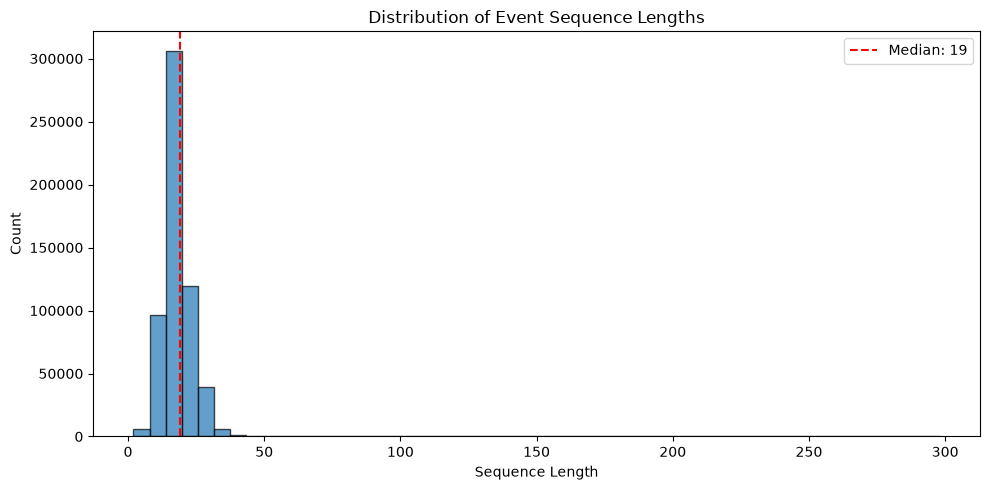

In [5]:
# sequence length distribution
import os
plot_dir = '../../results/plots'
os.makedirs(plot_dir, exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['seq_len'], bins=50, edgecolor='black', alpha=0.7)
ax.axvline(df['seq_len'].median(), color='r', linestyle='--', label=f'Median: {df["seq_len"].median():.0f}')
ax.set_xlabel('Sequence Length')
ax.set_ylabel('Count')
ax.set_title('Distribution of Event Sequence Lengths')
ax.legend()
plt.tight_layout()
plt.savefig(f'{plot_dir}/seq_length_distribution.png', dpi=100)
print(f'Saved: {plot_dir}/seq_length_distribution.png')

In [6]:
# analyze normal vs anomalous
normal_df = df[df['Label'] == 'Normal']
anomaly_df = df[df['Label'] == 'Anomaly']

print(f'Normal blocks: {len(normal_df)} ({len(normal_df)/len(df)*100:.2f}%)')
print(f'Anomalous blocks: {len(anomaly_df)} ({len(anomaly_df)/len(df)*100:.2f}%)')
print(f'\nSequence length by class:')
print(f'  Normal   - Min: {normal_df["seq_len"].min()}, Mean: {normal_df["seq_len"].mean():.1f}, Max: {normal_df["seq_len"].max()}')
print(f'  Anomaly  - Min: {anomaly_df["seq_len"].min()}, Mean: {anomaly_df["seq_len"].mean():.1f}, Max: {anomaly_df["seq_len"].max()}')

Normal blocks: 558223 (97.07%)
Anomalous blocks: 16838 (2.93%)

Sequence length by class:
  Normal   - Min: 13, Mean: 19.5, Max: 298
  Anomaly  - Min: 2, Mean: 17.1, Max: 284


In [7]:
# sample anomalous sequences for inspection
print('Sample anomalous sequences:')
for i, row in anomaly_df.head(3).iterrows():
    print(f'  BlockId: {row["BlockId"]}')
    print(f'  Sequence: {row["sequence"]}')
    print()

Sample anomalous sequences:
  BlockId: blk_-3544583377289625738
  Sequence: ['E5', 'E22', 'E5', 'E5', 'E11', 'E9', 'E11', 'E9', 'E11', 'E9', 'E3', 'E26', 'E26', 'E26', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3'

## Summary for Paper Table 1
- Total blocks: [computed below]
- Total events: [computed below]
- Unique event types: [computed below]
- Anomaly ratio: [computed below]
- Sequence length: min/median/mean/max [computed below]

In [8]:
# final summary stats
summary = {
    'Total Blocks': len(df),
    'Total Events': len(all_events),
    'Unique Event Types': len(event_counts),
    'Normal Blocks': len(normal_df),
    'Anomalous Blocks': len(anomaly_df),
    'Anomaly Ratio': f"{(len(anomaly_df)/len(df)*100):.2f}%",
    'Seq Len - Min': df['seq_len'].min(),
    'Seq Len - Median': df['seq_len'].median(),
    'Seq Len - Mean': f"{df['seq_len'].mean():.1f}",
    'Seq Len - Max': df['seq_len'].max(),
}

print('\n=== DATA STATISTICS FOR PAPER TABLE 1 ===')
for key, val in summary.items():
    print(f'{key}: {val}')


=== DATA STATISTICS FOR PAPER TABLE 1 ===
Total Blocks: 575061
Total Events: 11175629
Unique Event Types: 29
Normal Blocks: 558223
Anomalous Blocks: 16838
Anomaly Ratio: 2.93%
Seq Len - Min: 2
Seq Len - Median: 19.0
Seq Len - Mean: 19.4
Seq Len - Max: 298
